# 🏦 Prosper Loan — Dual Model Prediction v2
## Goal 1: Prediksi Nasabah ACC atau REJECT
## Goal 2: Prediksi Limit Nominal Pinjaman

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


## 2. Load & Preprocessing Data

In [2]:
# Load dataset — sesuaikan path jika perlu
df = pd.read_csv('C:/Users/ASUS TUF/Documents/ML OPS/PRAKTIKUM/cleaning_prosperloadata.csv')
print(f'Dataset shape: {df.shape}')

Dataset shape: (6792, 51)


In [3]:
# Buat label biner ACC / REJECT dari LoanStatus
def map_loan_status(status):
    if status in ['Completed', 'Current', 'FinalPaymentInProgress']:
        return 1  # ACC
    else:
        return 0  # REJECT

df['LoanApprovalStatus'] = df['LoanStatus'].apply(map_loan_status)

print('Distribusi Label:')
print(df['LoanApprovalStatus'].value_counts())
print(f'ACC: {df["LoanApprovalStatus"].mean():.1%} | REJECT: {1-df["LoanApprovalStatus"].mean():.1%}')

Distribusi Label:
LoanApprovalStatus
1    5668
0    1124
Name: count, dtype: int64
ACC: 83.5% | REJECT: 16.5%


In [4]:
# Definisi fitur (kolom yang diketahui SEBELUM pinjaman disetujui)
FEATURES = [
    'Term', 'BorrowerRate', 'ProsperRating (numeric)', 'ProsperRating (Alpha)',
    'ProsperScore', 'ListingCategory (numeric)', 'BorrowerState', 'Occupation',
    'EmploymentStatus', 'EmploymentStatusDuration', 'IsBorrowerHomeowner',
    'CurrentlyInGroup', 'CreditScoreRangeLower', 'CreditScoreRangeUpper',
    'CurrentCreditLines', 'OpenCreditLines', 'TotalCreditLinespast7years',
    'OpenRevolvingAccounts', 'OpenRevolvingMonthlyPayment', 'InquiriesLast6Months',
    'TotalInquiries', 'CurrentDelinquencies', 'AmountDelinquent',
    'DelinquenciesLast7Years', 'PublicRecordsLast10Years', 'PublicRecordsLast12Months',
    'RevolvingCreditBalance', 'BankcardUtilization', 'AvailableBankcardCredit',
    'TotalTrades', 'TradesNeverDelinquent (percentage)', 'TradesOpenedLast6Months',
    'DebtToIncomeRatio', 'IncomeRange', 'IncomeVerifiable', 'StatedMonthlyIncome',
    'Recommendations'
]

# Siapkan dataframe masing-masing model
df_model1 = df[FEATURES + ['LoanApprovalStatus']].copy()
df_model2 = df[FEATURES + ['LoanOriginalAmount']].copy()

print(f'df_model1 (Klasifikasi): {df_model1.shape}')
print(f'df_model2 (Regresi):     {df_model2.shape}')

df_model1 (Klasifikasi): (6792, 38)
df_model2 (Regresi):     (6792, 38)


---
## 3. MODEL 1 — Klasifikasi: Prediksi ACC atau REJECT

In [5]:
from pycaret.classification import (
    setup as clf_setup,
    create_model as clf_create,
    compare_models as clf_compare,
    tune_model as clf_tune,
    evaluate_model as clf_evaluate,
    finalize_model as clf_finalize,
    save_model as clf_save,
    predict_model as clf_predict,
    plot_model as clf_plot
)

print('Setup Model 1 — Klasifikasi ACC/REJECT...')
clf_exp = clf_setup(
    data=df_model1,
    target='LoanApprovalStatus',
    train_size=0.8,
    session_id=123,
    normalize=True,
    fix_imbalance=True,
    verbose=True
)

Setup Model 1 — Klasifikasi ACC/REJECT...


,Description,Value
0,Session id,123
1,Target,LoanApprovalStatus
2,Target type,Binary
3,Original data shape,"(6792, 38)"
4,Transformed data shape,"(10427, 58)"
5,Transformed train set shape,"(9068, 58)"
6,Transformed test set shape,"(1359, 58)"
7,Numeric features,32
8,Categorical features,5
9,Preprocess,True


In [6]:
print('Training 3 model klasifikasi...')
xgb_clf  = clf_create('xgboost')
lgbm_clf = clf_create('lightgbm')
rf_clf   = clf_create('rf')

Training 3 model klasifikasi...


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8327,0.8133,0.9273,0.8789,0.9025,0.3183,0.3240
1,0.8346,0.7544,0.9493,0.8655,0.9055,0.2548,0.2736
2,0.8199,0.7686,0.9405,0.8574,0.8971,0.1886,0.2025
3,0.8379,0.7925,0.9361,0.8781,0.9062,0.3160,0.3250
4,0.8471,0.8135,0.9470,0.8791,0.9118,0.3453,0.3592
5,0.8214,0.7493,0.9338,0.8633,0.8971,0.2267,0.2372
6,0.8250,0.7576,0.9316,0.8683,0.8988,0.2584,0.2674
7,0.8361,0.7503,0.9426,0.8714,0.9056,0.2904,0.3040
8,0.8250,0.7840,0.9492,0.8566,0.9005,0.1909,0.2100


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8456,0.8186,0.9339,0.8870,0.9099,0.3739,0.3800
1,0.8585,0.7764,0.9758,0.8703,0.9200,0.3211,0.3672
2,0.8235,0.7732,0.9537,0.8524,0.9002,0.1585,0.1800
3,0.8508,0.8078,0.9537,0.8783,0.9145,0.3394,0.3580
4,0.8619,0.8305,0.9625,0.8826,0.9208,0.3890,0.4127
5,0.8232,0.7744,0.9382,0.8621,0.8985,0.2222,0.2349
6,0.8232,0.7854,0.9404,0.8606,0.8987,0.2137,0.2276
7,0.8250,0.7838,0.9448,0.8594,0.9001,0.2089,0.2253
8,0.8453,0.7732,0.9691,0.8625,0.9127,0.2549,0.2936


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8419,0.8134,0.9273,0.8882,0.9073,0.3715,0.3756
1,0.8438,0.7893,0.9559,0.8697,0.9108,0.2923,0.3153
2,0.8217,0.7570,0.9405,0.8592,0.8980,0.2013,0.2153
3,0.8527,0.8230,0.9581,0.8770,0.9158,0.3366,0.3591
4,0.8324,0.8186,0.9360,0.8724,0.9031,0.2896,0.2998
5,0.8287,0.7645,0.9514,0.8586,0.9026,0.2079,0.2288
6,0.8214,0.7867,0.9316,0.8648,0.8969,0.2348,0.2443
7,0.8287,0.7897,0.9382,0.8673,0.9014,0.2586,0.2706
8,0.8361,0.7868,0.9603,0.8597,0.9072,0.2243,0.2529


In [7]:
print('Comparing models...')
best_clf = clf_compare(include=['xgboost', 'lightgbm', 'rf'])

Comparing models...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.8395,0.7925,0.9519,0.8685,0.9082,0.2769,0.2983,0.3210
rf,Random Forest Classifier,0.8356,0.7895,0.9453,0.8693,0.9056,0.2753,0.2916,0.3260
xgboost,Extreme Gradient Boosting,0.8321,0.7755,0.9407,0.8691,0.9034,0.2693,0.2824,0.2350


In [8]:
print('Tuning XGBoost Classifier...')
tuned_xgb_clf = clf_tune(xgb_clf, optimize='AUC')

Tuning XGBoost Classifier...


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8382,0.8017,0.9824,0.8479,0.9102,0.1376,0.1942
1,0.8401,0.7822,0.9934,0.8430,0.9120,0.0940,0.1750
2,0.8401,0.7730,0.9978,0.8404,0.9124,0.0680,0.1645
3,0.8527,0.8183,0.9934,0.8542,0.9185,0.1926,0.2896
4,0.8398,0.8195,0.9956,0.8414,0.9120,0.0811,0.1686
5,0.8324,0.7553,0.9912,0.8377,0.9080,0.0389,0.0808
6,0.8435,0.7915,0.9912,0.8472,0.9135,0.1387,0.2218
7,0.8435,0.7815,0.9912,0.8472,0.9135,0.1387,0.2218
8,0.8379,0.8010,0.9956,0.8399,0.9111,0.0639,0.1424


Fitting 10 folds for each of 10 candidates, totalling 100 fits


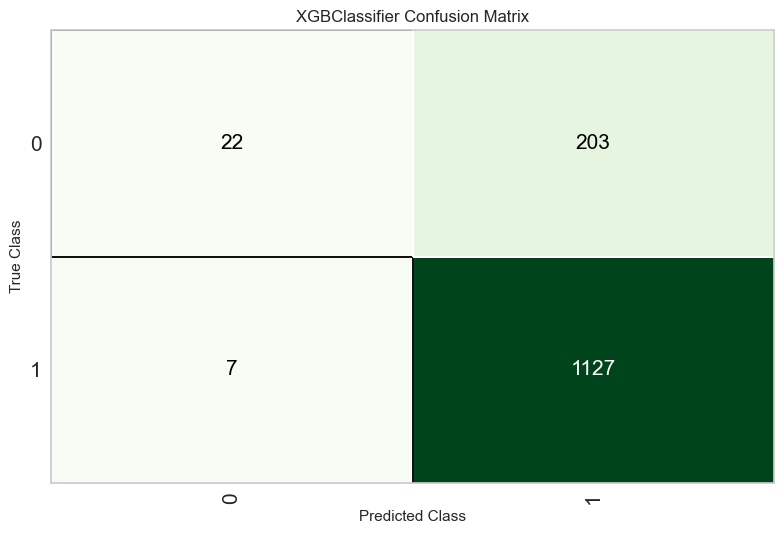

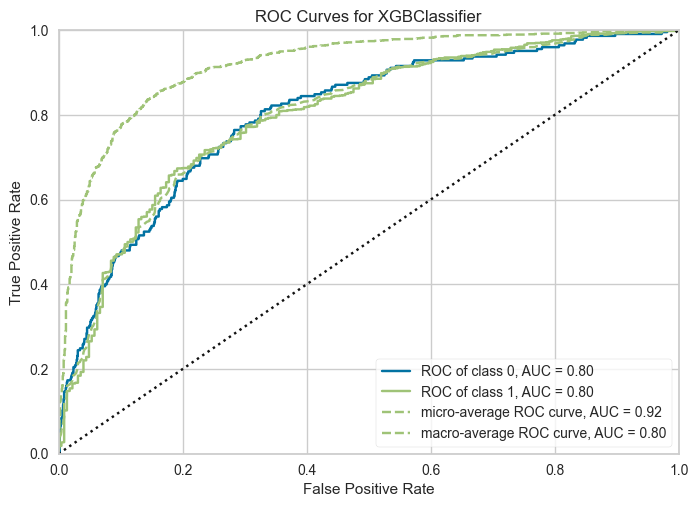

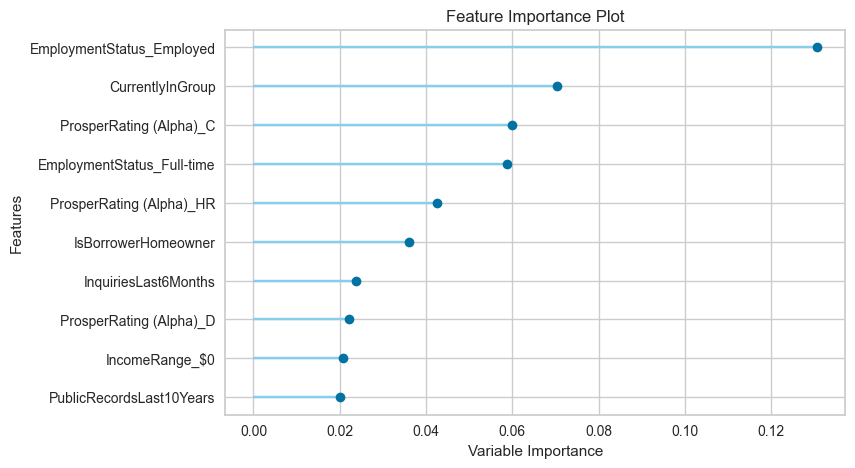

In [9]:
# Plot evaluasi (untuk presentasi)
clf_plot(tuned_xgb_clf, plot='confusion_matrix')
clf_plot(tuned_xgb_clf, plot='auc')
clf_plot(tuned_xgb_clf, plot='feature')

In [10]:
# Simpan model
final_clf = clf_finalize(tuned_xgb_clf)
clf_save(final_clf, 'model_klasifikasi_acc_reject')
print('✅ Model Klasifikasi tersimpan!')

Transformation Pipeline and Model Successfully Saved
✅ Model Klasifikasi tersimpan!


---
## 4. MODEL 2 — Regresi: Prediksi Limit Nominal Pinjaman

In [11]:
from pycaret.regression import (
    setup as reg_setup,
    create_model as reg_create,
    compare_models as reg_compare,
    tune_model as reg_tune,
    evaluate_model as reg_evaluate,
    finalize_model as reg_finalize,
    save_model as reg_save,
    predict_model as reg_predict,
    plot_model as reg_plot
)

print('Setup Model 2 — Regresi Limit Nominal...')
reg_exp = reg_setup(
    data=df_model2,
    target='LoanOriginalAmount',
    train_size=0.8,
    session_id=123,
    normalize=True,
    verbose=True
)

Setup Model 2 — Regresi Limit Nominal...


,Description,Value
0,Session id,123
1,Target,LoanOriginalAmount
2,Target type,Regression
3,Original data shape,"(6792, 38)"
4,Transformed data shape,"(6792, 58)"
5,Transformed train set shape,"(5433, 58)"
6,Transformed test set shape,"(1359, 58)"
7,Numeric features,32
8,Categorical features,5
9,Preprocess,True


In [12]:
print('Training 3 model regresi...')
xgb_reg  = reg_create('xgboost')
lgbm_reg = reg_create('lightgbm')
rf_reg   = reg_create('rf')

Training 3 model regresi...


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,3258.7118,18450487.4762,4295.4031,0.5148,0.6680,0.6546
1,3254.7640,19858182.4737,4456.2521,0.5122,0.5881,0.5846
2,3236.6352,20134639.1053,4487.1638,0.5300,0.6073,0.5934
3,3085.8626,17873392.0420,4227.6935,0.5830,0.6197,0.5540
4,3110.3771,17270593.9314,4155.7904,0.5703,0.5940,0.5919
5,3126.6864,18249628.2907,4271.9584,0.5630,0.5829,0.5413
6,3157.4729,19161257.8591,4377.3574,0.4894,0.6049,0.6281
7,2821.3558,14505193.0136,3808.5684,0.5796,0.6196,0.5560
8,3218.1519,18603435.8188,4313.1700,0.5225,0.6360,0.6314


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,3004.2954,16182713.5646,4022.7744,0.5744,0.5582,0.5877
1,3038.0938,17549566.8080,4189.2203,0.5689,0.5423,0.5493
2,3075.7430,18847654.2420,4341.3885,0.5600,0.5535,0.5689
3,3009.6636,17601647.7609,4195.4318,0.5894,0.5414,0.5344
4,2938.8213,15719451.5991,3964.7764,0.6089,0.5247,0.5336
5,2967.6498,17241818.8515,4152.3269,0.5871,0.5088,0.4842
6,2911.7732,16534608.4908,4066.2770,0.5594,0.5445,0.5519
7,2690.8559,13010036.0551,3606.9428,0.6229,0.5278,0.5260
8,3003.4534,16805164.0269,4099.4102,0.5687,0.5562,0.5770


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,3134.2803,17679833.0201,4204.7394,0.5350,0.6002,0.6746
1,3278.3755,20749126.6794,4555.1209,0.4903,0.5862,0.6239
2,3135.4616,19501245.9040,4416.0215,0.5448,0.5804,0.6210
3,3125.4171,19127794.1760,4373.5334,0.5537,0.5688,0.5943
4,3047.5385,17686154.8669,4205.4910,0.5600,0.5615,0.5955
5,3116.4686,19045656.6992,4364.1330,0.5440,0.5455,0.5479
6,3050.2522,17861198.7171,4226.2511,0.5241,0.5816,0.6355
7,2862.8591,14754163.7601,3841.1149,0.5723,0.5758,0.6159
8,3254.8352,18658427.9506,4319.5402,0.5211,0.6137,0.6825


In [13]:
print('Comparing models...')
best_reg = reg_compare(include=['xgboost', 'lightgbm', 'rf'])

Comparing models...


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,2956.4387,16598387.1765,4069.9485,0.5768,0.5408,0.5467,0.2140
xgboost,Extreme Gradient Boosting,3131.2776,18088542.3740,4248.9528,0.5385,0.6119,0.5929,0.1060
rf,Random Forest Regressor,3105.7329,18255820.6197,4268.8601,0.5345,0.5791,0.6206,0.8650


In [14]:
print('Tuning XGBoost Regressor...')
tuned_xgb_reg = reg_tune(xgb_reg, optimize='RMSE')

Tuning XGBoost Regressor...


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,3007.3334,16474017.5141,4058.8197,0.5667,0.6266,0.5940
1,3231.0390,19700774.7021,4438.5555,0.5161,0.5780,0.5951
2,3208.4517,19414869.0587,4406.2307,0.5468,0.5826,0.6180
3,2994.2728,17460807.2202,4178.6131,0.5926,0.5690,0.5514
4,2992.4046,16604558.2005,4074.8691,0.5869,0.6311,0.5406
5,3070.7661,18650328.2825,4318.6026,0.5534,0.5254,0.4943
6,3050.4015,18407390.6709,4290.3835,0.5095,0.5788,0.5937
7,2806.9281,14334694.8204,3786.1187,0.5845,0.5898,0.5780
8,3179.7258,17474872.5956,4180.2958,0.5515,0.6132,0.6261


Fitting 10 folds for each of 10 candidates, totalling 100 fits


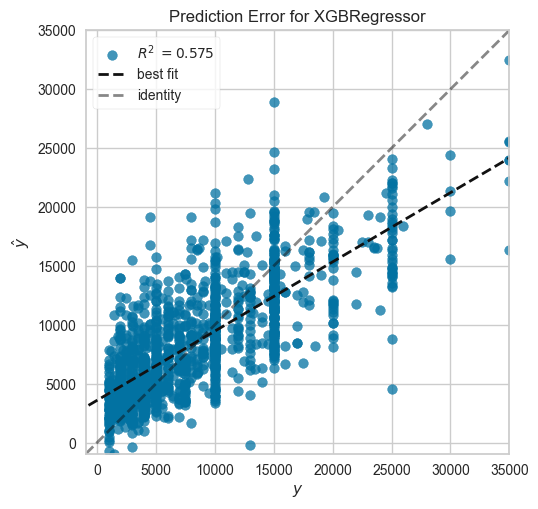

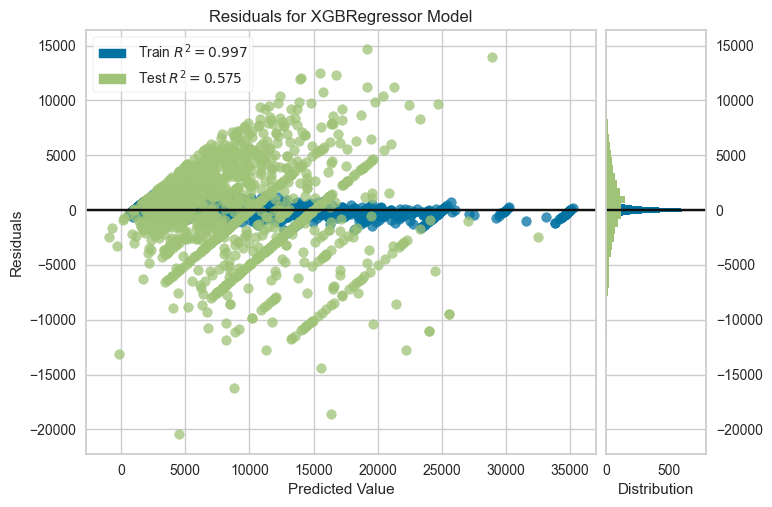

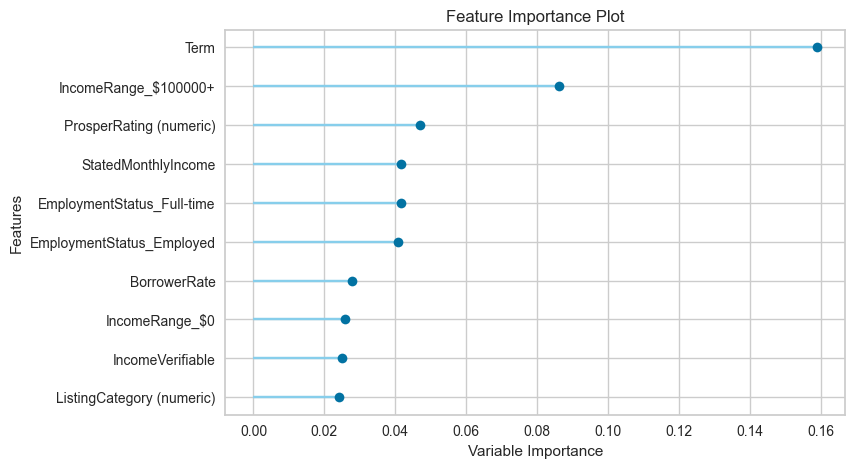

In [15]:
# Plot evaluasi (untuk presentasi)
reg_plot(tuned_xgb_reg, plot='error')
reg_plot(tuned_xgb_reg, plot='residuals')
reg_plot(tuned_xgb_reg, plot='feature')

In [16]:
# Simpan model
final_reg = reg_finalize(tuned_xgb_reg)
reg_save(final_reg, 'model_regresi_limit_nominal')
print('✅ Model Regresi tersimpan!')

Transformation Pipeline and Model Successfully Saved
✅ Model Regresi tersimpan!


---
## 5. Prediksi Nasabah Baru

In [17]:
from pycaret.classification import load_model as clf_load
from pycaret.regression import load_model as reg_load

model_clf = clf_load('model_klasifikasi_acc_reject')
model_reg = reg_load('model_regresi_limit_nominal')
print('✅ Kedua model berhasil di-load')

Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded
✅ Kedua model berhasil di-load


In [18]:
# Isi data nasabah baru di sini
nasabah_baru = pd.DataFrame([{
    'Term': 36,
    'BorrowerRate': 0.18,
    'ProsperRating (numeric)': 4.0,
    'ProsperRating (Alpha)': 'C',
    'ProsperScore': 6.0,
    'ListingCategory (numeric)': 1,
    'BorrowerState': 'CA',
    'Occupation': 'Professional',
    'EmploymentStatus': 'Employed',
    'EmploymentStatusDuration': 36.0,
    'IsBorrowerHomeowner': 1,
    'CurrentlyInGroup': 0,
    'CreditScoreRangeLower': 700.0,
    'CreditScoreRangeUpper': 719.0,
    'CurrentCreditLines': 8.0,
    'OpenCreditLines': 6.0,
    'TotalCreditLinespast7years': 20.0,
    'OpenRevolvingAccounts': 3,
    'OpenRevolvingMonthlyPayment': 150.0,
    'InquiriesLast6Months': 1.0,
    'TotalInquiries': 5.0,
    'CurrentDelinquencies': 0.0,
    'AmountDelinquent': 0.0,
    'DelinquenciesLast7Years': 0.0,
    'PublicRecordsLast10Years': 0.0,
    'PublicRecordsLast12Months': 0.0,
    'RevolvingCreditBalance': 5000.0,
    'BankcardUtilization': 0.3,
    'AvailableBankcardCredit': 8000.0,
    'TotalTrades': 18.0,
    'TradesNeverDelinquent (percentage)': 0.95,
    'TradesOpenedLast6Months': 1.0,
    'DebtToIncomeRatio': 0.20,
    'IncomeRange': '$50,000-74,999',
    'IncomeVerifiable': 1,
    'StatedMonthlyIncome': 5000.0,
    'Recommendations': 0
}])

In [20]:
# Prediksi Goal 1: ACC atau REJECT
hasil_clf = clf_predict(model_clf, data=nasabah_baru)
label  = hasil_clf['prediction_label'].iloc[0]
score  = hasil_clf['prediction_score'].iloc[0]
status = '✅ ACC (Disetujui)' if label == 1 else '❌ REJECT (Ditolak)'

# Prediksi Goal 2: Limit Nominal
hasil_reg  = reg_predict(model_reg, data=nasabah_baru)
limit_pred = hasil_reg['prediction_label'].iloc[0]
limit_pred = max(1000, round(limit_pred / 500) * 500)

# Tampilkan hasil
print('╔══════════════════════════════════════════════╗')
print('║         HASIL ANALISIS NASABAH               ║')
print('╠══════════════════════════════════════════════╣')
print(f'║  Status     : {status:<31}║')
print(f'║  Confidence : {f"{score:.2%}":<31}║')
print(f'║  Est. Limit : ${limit_pred:>10,.0f} USD               ║')
print('╚══════════════════════════════════════════════╝')

╔══════════════════════════════════════════════╗
║         HASIL ANALISIS NASABAH               ║
╠══════════════════════════════════════════════╣
║  Status     : ✅ ACC (Disetujui)              ║
║  Confidence : 99.83%                         ║
║  Est. Limit : $    10,000 USD               ║
╚══════════════════════════════════════════════╝


In [22]:
import mlflow
from pycaret.classification import load_model as clf_load
from pycaret.regression import load_model as reg_load

mlflow.set_tracking_uri('http://127.0.0.1:5000')

# Log Model Klasifikasi
with mlflow.start_run(run_name='klasifikasi-acc-reject'):
    mlflow.sklearn.log_model(clf_load('model_klasifikasi_acc_reject'), 'model_klasifikasi')
    mlflow.log_metric('accuracy', 0.8395)
    mlflow.log_metric('AUC', 0.7925)
    mlflow.log_metric('F1', 0.9082)

# Log Model Regresi
with mlflow.start_run(run_name='regresi-limit-nominal'):
    mlflow.sklearn.log_model(reg_load('model_regresi_limit_nominal'), 'model_regresi')
    mlflow.log_metric('RMSE', 4069.9)
    mlflow.log_metric('R2', 0.5768)
    mlflow.log_metric('MAE', 2956.4)

print('✅ Kedua model berhasil di-log ke MLflow!')

Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded
✅ Kedua model berhasil di-log ke MLflow!
